In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [33]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 16.4 MB/s eta 0:00:01
   -------- ------------------------------- 2.1/9.9 MB 9.0 MB/s eta 0:00:01
   ---------------- ----------------------- 4.2/9.9 MB 9.7 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 10.1 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/9.9 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 9.3 MB/s  0:00:01



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [9]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [10]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

# CLEANING

In [11]:
# Menghapus pelanggan yang lahir di bawah tahun 1900
df = df[df['Year_Birth'] > 1900]

In [12]:
# Cek korelasi antar belanjaan, misal: apakah orang kaya lebih suka beli Wine?
df[['Income', 'MntWines', 'MntMeatProducts']].corr()

,Income,MntWines,MntMeatProducts
Income,1.000000,0.578481,0.584361
MntWines,0.578481,1.000000,0.561993
MntMeatProducts,0.584361,0.561993,1.000000


In [13]:
median_income = df['Income'].median()
df['Income'] = df['Income'].fillna(median_income)

In [14]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [15]:
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

Korelasi

In [16]:
# Menghitung korelasi (secara default menggunakan metode Pearson)
korelasi = df.corr(numeric_only=True)

In [17]:
# Menampilkan korelasi kolom Income dengan kolom lainnya
print(korelasi['Income'].sort_values(ascending=False))

Income                 1.000000
NumCatalogPurchases    0.586751
MntMeatProducts        0.577524
MntWines               0.576732
NumStorePurchases      0.527347
MntFishProducts        0.437215
MntSweetProducts       0.435918
MntFruits              0.428191
NumWebPurchases        0.380847
AcceptedCmp5           0.333978
MntGoldProds           0.321082
AcceptedCmp1           0.275140
AcceptedCmp4           0.182931
Response               0.133122
AcceptedCmp2           0.087672
Teenhome               0.019117
ID                     0.013736
Recency               -0.003207
AcceptedCmp3          -0.015953
Complain              -0.024866
NumDealsPurchases     -0.082089
Year_Birth            -0.162346
Kidhome               -0.424888
NumWebVisitsMonth     -0.549429
Name: Income, dtype: float64


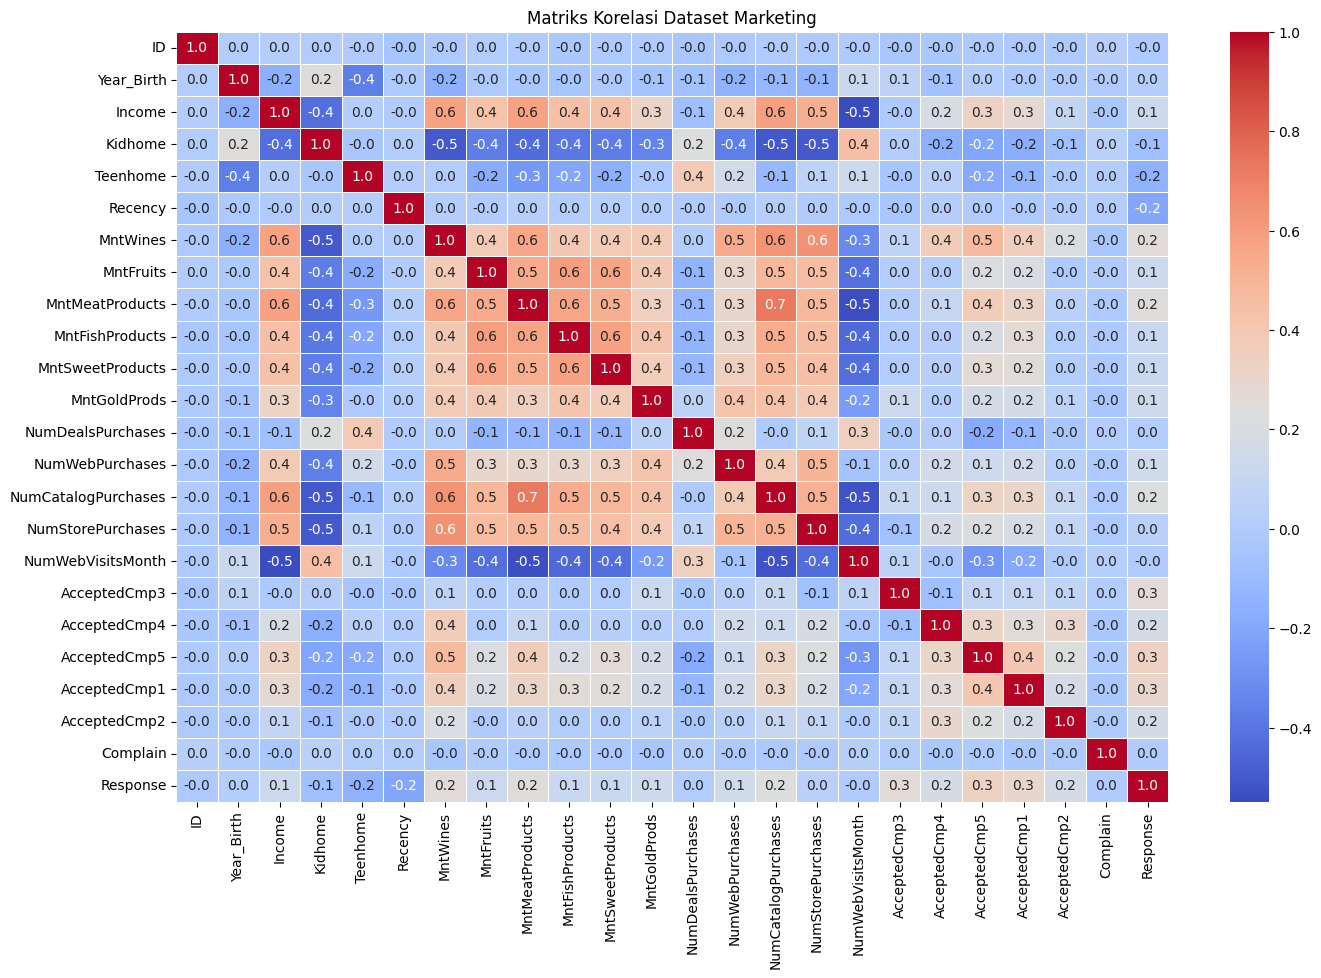

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mengatur ukuran gambar
plt.figure(figsize=(16, 10))

# Membuat heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.5)

plt.title('Matriks Korelasi Dataset Marketing')
plt.show()

In [19]:
# Melihat rata-rata belanja wine berdasarkan jumlah anak
print(df.groupby('Kidhome')['MntWines'].mean())

# Atau melihat rata-rata income berdasarkan tingkat pendidikan
print(df.groupby('Education')['Income'].mean().sort_values())

Kidhome
0    451.281177
1    104.503341
2     74.791667
Name: MntWines, dtype: float64
Education
Basic         20306.259259
2n Cycle      47681.268657
Graduation    52707.222715
Master        52896.662162
PhD           56039.647423
Name: Income, dtype: float64


# Feature Engineering

In [20]:
df['Total_Spend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Age'] = 2024 - df['Year_Birth']

In [21]:
# Pilih fitur yang paling berpengaruh untuk clustering
features = ['Income', 'Total_Spend', 'Age']
x = df[features]

In [22]:
# Scaling data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

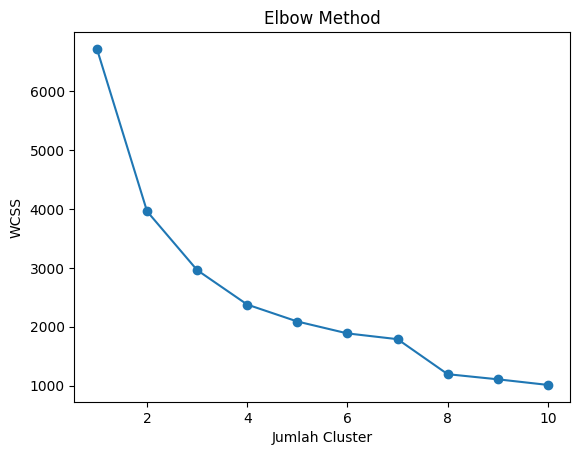

In [ ]:
# Elbow Method 
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

# K-Means

In [24]:
# 1. Menjalankan K-Means dengan 4 cluster
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_transform(x_scaled).argmin(axis=1) # atau kmeans.fit_predict(x_scaled)

# 2. Melihat rata-rata setiap kelompok untuk interpretasi
cluster_profile = df.groupby('Cluster')[['Income', 'Total_Spend', 'Age']].mean().sort_values(by='Income', ascending=False)
print(cluster_profile)

               Income  Total_Spend        Age
Cluster                                      
1        74923.066079  1275.955947  46.863436
3        72470.520000  1256.135000  67.617500
0        45618.203571   269.369643  65.432143
2        34365.775213   148.800729  46.524909


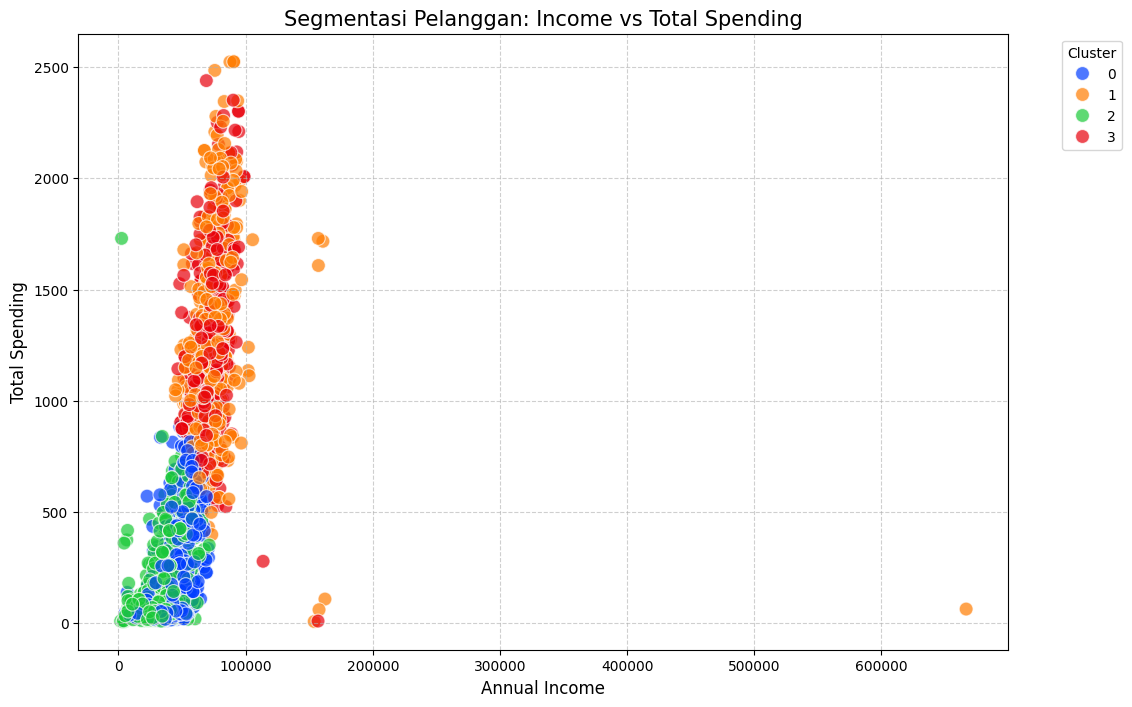

In [25]:
plt.figure(figsize=(12, 8))
# Visualisasi Income vs Total Spend dengan warna per Cluster
sns.scatterplot(data=df, x='Income', y='Total_Spend', hue='Cluster',
                palette='bright', s=100, alpha=0.7)

plt.title('Segmentasi Pelanggan: Income vs Total Spending', fontsize=15)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [26]:
df.to_csv('data_clean.csv', index=False)
print("File BERHASIL disimpan!")

File BERHASIL disimpan!


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px 

st.set_page_config(page_title="Customer Insight Tool", layout="wide")

# 1. Load Data
@st.cache_data
def load_data():
    df = pd.read_csv('data_clean.csv')
    cluster_names = {
        1: "💎 The Prime Affluents (Sultan)",
        3: "👴 The Golden Seniors",
        0: "🏠 The Frugal Elders",
        2: "🌱 The Budget Aspirants"
    }
    df['Segment_Name'] = df['Cluster'].map(cluster_names)
    return df

df = load_data()

# --- SIDEBAR ---
st.sidebar.title("🔍 Filter Dashboard")
selected_segments = st.sidebar.multiselect(
    "Pilih Kelompok Pelanggan:",
    options=df['Segment_Name'].unique(),
    default=df['Segment_Name'].unique()
)

filtered_df = df[df['Segment_Name'].isin(selected_segments)]

# --- HEADER ---
st.title("🎯 Strategi Pemasaran Berdasarkan Segmen")
st.markdown(f"Saat ini menganalisis **{len(filtered_df)}** profil pelanggan.")

# --- ROW 1: SUMMARY CARDS ---
col1, col2, col3, col4 = st.columns(4)
col1.metric("💰 Rata-rata Pendapatan", f"${filtered_df['Income'].mean():,.0f}")
col2.metric("🛒 Rata-rata Belanja", f"${filtered_df['Total_Spend'].mean():,.0f}")
col3.metric("🎂 Rata-rata Usia", f"{filtered_df['Age'].mean():.0f} Tahun")
col4.metric("📈 Respon Promo", f"{filtered_df['Response'].mean()*100:.1f}%")

st.divider()

# --- ROW 2: BUSINESS INSIGHTS (The "Storytelling" Part) ---
st.subheader("💡 Apa yang Harus Dilakukan?")
c1, c2 = st.columns([2, 1])

with c1:
    fig = px.scatter(filtered_df, x='Income', y='Total_Spend', 
                     color='Segment_Name', size='Total_Spend',
                     hover_data=['Age', 'Education'],
                     title="Hubungan Pendapatan vs Total Belanja")
    st.plotly_chart(fig, use_container_width=True)

with c2:
    st.info("**Rekomendasi Bisnis:**")
    if "💎 The Prime Affluents (Sultan)" in selected_segments:
        st.write("- **Sultan:** Fokus pada produk Wine dan Meat premium. Jangan beri terlalu banyak diskon, mereka lebih suka eksklusivitas.")
    if "👴 The Golden Seniors" in selected_segments:
        st.write("- **Seniors:** Gunakan katalog fisik. Mereka punya daya beli tinggi tapi lebih suka cara belanja tradisional.")
    if "🌱 The Budget Aspirants" in selected_segments:
        st.write("- **Budget Aspirants:** Fokus pada promo 'Buy 1 Get 1' dan kampanye via website.")

# --- ROW 3: PRODUCT ANALYSIS ---
st.divider()
st.subheader("🍷 Produk Apa yang Paling Laku?")
products = {'MntWines': 'Wine', 'MntFruits': 'Buah', 'MntMeatProducts': 'Daging', 
            'MntFishProducts': 'Ikan', 'MntSweetProducts': 'Permen', 'MntGoldProds': 'Emas'}

df_melted = filtered_df.groupby('Segment_Name')[list(products.keys())].mean().reset_index()
df_melted = df_melted.melt(id_vars='Segment_Name', var_name='Produk', value_name='Rata-rata Belanja')
df_melted['Produk'] = df_melted['Produk'].map(products)

fig_bar = px.bar(df_melted, x='Segment_Name', y='Rata-rata Belanja', color='Produk', barmode='group')
st.plotly_chart(fig_bar, use_container_width=True)

Overwriting app.py


In [28]:
!npm install -g localtunnel -q


added 22 packages in 3s

3 packages are looking for funding
  run `npm fund` for details


npm notice
npm notice New major version of npm available! 10.9.2 -> 11.12.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.12.1
npm notice To update run: npm install -g npm@11.12.1
npm notice


In [ ]:
# pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!curl ipv4.icanhazip.com

!pip install streamlit -q
!streamlit run app.py & npx localtunnel --port 8501

192.135.210.20


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100     15 100     15   0      0    580      0                              0
100     15 100     15   0      0    578      0                              0
100     15 100     15   0      0    575      0                              0

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C
